# 97 - 速度ベンチマークと実用性評価

ArcFace 512次元、約75K顔埋め込みに対する各種検索手法の速度を包括的にベンチマークし、
実用性を評価する。

## 比較手法
1. **Brute-force** — numpy コサイン類似度（全件線形探索）
2. **HNSW** (DuckDB vss) — グラフベース近似最近傍
3. **ITQ カスケード** — ハミング距離候補選択 + コサイン類似度リランキング
4. **+Overlap** — オーバーラップバンドインデックス付き
5. **+Pivot** — ピボットフィルタリング付き

## 評価指標
- Mean / Median / P95 レイテンシ
- QPS (Queries Per Second)
- メモリ使用量
- スケール外挿 (100K, 500K, 1M)

## 入力
- `data/images.duckdb` (`face_detections` テーブル, model_name='buffalo_l')
- ITQ 128bit モデル（本 notebook 内で学習）

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from pathlib import Path
from collections import Counter

from image_vector_poc.search.lsh.itq import ITQLSH
from image_vector_poc.search.lsh.cascade import CascadeSearcher

DB_PATH = Path("../data/images.duckdb")
MODEL_DIR = Path("../data/itq_models")
N_BITS = 128
TOP_K = 10
N_QUERIES = 20
N_RUNS = 3

conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

rows = conn.execute("""
    SELECT f.face_id, f.embedding
    FROM face_detections f
    WHERE f.model_name = 'insightface/buffalo_l'
    ORDER BY f.face_id
""").fetchall()

face_ids = [r[0] for r in rows]
embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / norms
N_TOTAL = len(embeddings)

rng = np.random.default_rng(42)
query_idx = rng.choice(N_TOTAL, N_QUERIES, replace=False)
query_embs = embeddings[query_idx]

print(f"Corpus: {N_TOTAL:,} faces, Queries: {N_QUERIES}, Runs: {N_RUNS}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Corpus: 75,162 faces, Queries: 20, Runs: 3


## 1. Brute-force ベースライン

In [2]:
def benchmark_method(search_fn, n_runs=N_RUNS):
    """search_fn(query_emb) -> results. Returns latency stats in ms."""
    all_times = []
    for _ in range(n_runs):
        for q in query_embs:
            t0 = time.perf_counter()
            search_fn(q)
            elapsed = (time.perf_counter() - t0) * 1000  # ms
            all_times.append(elapsed)
    all_times = np.array(all_times)
    return {
        "mean_ms": all_times.mean(),
        "median_ms": np.median(all_times),
        "p95_ms": np.percentile(all_times, 95),
        "qps": 1000.0 / all_times.mean(),
    }

# Brute-force
def brute_force_search(q):
    sims = embeddings @ q
    return np.argsort(-sims)[:TOP_K]

bf_stats = benchmark_method(brute_force_search)
print(f"Brute-force: mean={bf_stats['mean_ms']:.2f}ms, median={bf_stats['median_ms']:.2f}ms, p95={bf_stats['p95_ms']:.2f}ms, QPS={bf_stats['qps']:.0f}")

Brute-force: mean=7.10ms, median=6.32ms, p95=9.10ms, QPS=141


## 2. HNSW (DuckDB)

In [3]:
def hnsw_search(q):
    q_list = [float(x) for x in q]
    return conn.execute(f"""
        SELECT f.face_id
        FROM face_detections f
        WHERE f.model_name = 'insightface/buffalo_l'
        ORDER BY array_cosine_distance(f.embedding, ?::FLOAT[512])
        LIMIT {TOP_K}
    """, [q_list]).fetchall()

hnsw_stats = benchmark_method(hnsw_search)
print(f"HNSW: mean={hnsw_stats['mean_ms']:.2f}ms, median={hnsw_stats['median_ms']:.2f}ms, p95={hnsw_stats['p95_ms']:.2f}ms, QPS={hnsw_stats['qps']:.0f}")

HNSW: mean=18.92ms, median=17.05ms, p95=23.83ms, QPS=53


## 3. ITQ カスケード検索

In [4]:
# ITQ モデル読み込みとインデックス構築
model_path = MODEL_DIR / f"itq_arcface_{N_BITS}bit.pkl"
if model_path.exists():
    itq = ITQLSH.load(str(model_path))
else:
    itq = ITQLSH(n_bits=N_BITS, seed=42)
    itq.fit(embeddings)

searcher = CascadeSearcher(itq)
searcher.build_index(embeddings, metadata=face_ids, show_progress=False)
hashes = itq.transform(embeddings)

# 候補数別ベンチマーク
CANDIDATE_SIZES = [200, 500, 1000, 2000]
cascade_stats = {}

for cand in CANDIDATE_SIZES:
    def cascade_search(q, c=cand):
        return searcher.search(q, candidates=c, top_k=TOP_K)
    
    stats = benchmark_method(cascade_search)
    cascade_stats[cand] = stats
    print(f"ITQ cascade (cand={cand:4d}): mean={stats['mean_ms']:.2f}ms, QPS={stats['qps']:.0f}")

ITQ cascade (cand= 200): mean=5.31ms, QPS=188


ITQ cascade (cand= 500): mean=5.35ms, QPS=187


ITQ cascade (cand=1000): mean=9.13ms, QPS=110


ITQ cascade (cand=2000): mean=8.39ms, QPS=119


## 4. メモリ使用量比較

Method               |   Embeddings |        Index |       Params |        Total
---------------------------------------------------------------------------
Brute-force          |      153.9MB |        0.0MB |        0.0MB |      153.9MB
HNSW                 |      153.9MB |       19.2MB |        0.0MB |      173.2MB
ITQ cascade          |      153.9MB |        1.2MB |        0.3MB |      155.5MB
ITQ (no emb)         |        0.0MB |        1.2MB |        0.3MB |        1.5MB


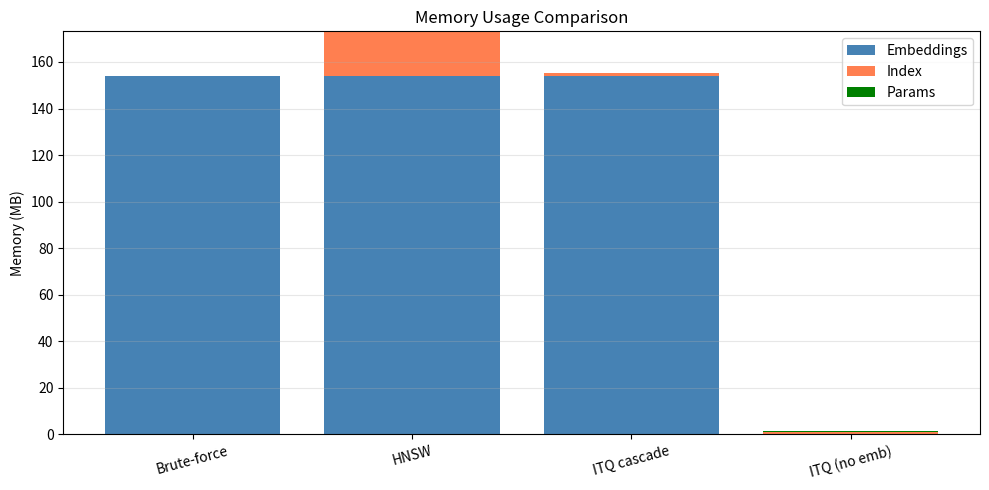

In [5]:
dim = embeddings.shape[1]
n = N_TOTAL

mem_data = {
    "Brute-force": {
        "embeddings": n * dim * 4,  # float32
        "index": 0,
        "params": 0,
    },
    "HNSW": {
        "embeddings": n * dim * 4,
        "index": n * 64 * 4,  # M=16 neighbors * 4 layers estimate
        "params": 0,
    },
    "ITQ cascade": {
        "embeddings": n * dim * 4,
        "index": n * N_BITS // 8,  # binary hashes
        "params": dim * 4 + dim * N_BITS * 4 + N_BITS * N_BITS * 4,  # mean + pca + rotation
    },
    "ITQ (no emb)": {
        "embeddings": 0,
        "index": n * N_BITS // 8,
        "params": dim * 4 + dim * N_BITS * 4 + N_BITS * N_BITS * 4,
    },
}

print(f"{'Method':<20} | {'Embeddings':>12} | {'Index':>12} | {'Params':>12} | {'Total':>12}")
print("-" * 75)
for method, mem in mem_data.items():
    total = sum(mem.values())
    print(f"{method:<20} | {mem['embeddings']/1e6:>10.1f}MB | {mem['index']/1e6:>10.1f}MB | {mem['params']/1e6:>10.1f}MB | {total/1e6:>10.1f}MB")

# バーチャート
fig, ax = plt.subplots(figsize=(10, 5))
methods = list(mem_data.keys())
emb_sizes = [mem_data[m]["embeddings"]/1e6 for m in methods]
idx_sizes = [mem_data[m]["index"]/1e6 for m in methods]
param_sizes = [mem_data[m]["params"]/1e6 for m in methods]

x = np.arange(len(methods))
ax.bar(x, emb_sizes, label="Embeddings", color="steelblue")
ax.bar(x, idx_sizes, bottom=emb_sizes, label="Index", color="coral")
ax.bar(x, param_sizes, bottom=[e+i for e,i in zip(emb_sizes, idx_sizes)], label="Params", color="green")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)
ax.set_ylabel("Memory (MB)")
ax.set_title("Memory Usage Comparison")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 5. スケール分析と外挿

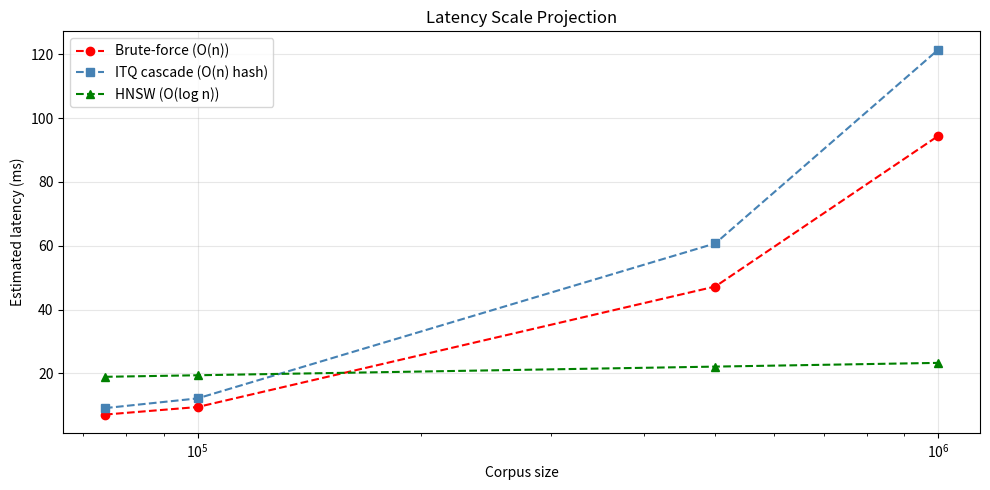

外挿レイテンシ推定:
      Size |  Brute-force |  ITQ cascade |         HNSW
    75,000 |        7.1ms |        9.1ms |       18.9ms
   100,000 |        9.4ms |       12.1ms |       19.4ms
   500,000 |       47.2ms |       60.7ms |       22.1ms
 1,000,000 |       94.4ms |      121.5ms |       23.3ms


In [6]:
# スケール外挿: レイテンシはデータサイズに比例すると仮定
scale_sizes = [75_000, 100_000, 500_000, 1_000_000]
bf_base = bf_stats["mean_ms"]
cascade_base = cascade_stats[1000]["mean_ms"]

fig, ax = plt.subplots(figsize=(10, 5))

# Brute-force: O(n)
bf_projected = [bf_base * s / N_TOTAL for s in scale_sizes]
ax.plot(scale_sizes, bf_projected, "o--", label="Brute-force (O(n))", color="red")

# ITQ cascade (candidates固定): O(n) for hash sort + O(candidates) for rerank
# ハミングソートは O(n)、リランクは O(candidates)
cascade_projected = [cascade_base * s / N_TOTAL for s in scale_sizes]
ax.plot(scale_sizes, cascade_projected, "s--", label="ITQ cascade (O(n) hash)", color="steelblue")

# HNSW: O(log n) 概算
hnsw_base = hnsw_stats["mean_ms"]
hnsw_projected = [hnsw_base * np.log(s) / np.log(N_TOTAL) for s in scale_sizes]
ax.plot(scale_sizes, hnsw_projected, "^--", label="HNSW (O(log n))", color="green")

ax.set_xlabel("Corpus size")
ax.set_ylabel("Estimated latency (ms)")
ax.set_title("Latency Scale Projection")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale("log")
plt.tight_layout()
plt.show()

print("外挿レイテンシ推定:")
print(f"{'Size':>10} | {'Brute-force':>12} | {'ITQ cascade':>12} | {'HNSW':>12}")
for i, s in enumerate(scale_sizes):
    print(f"{s:>10,} | {bf_projected[i]:>10.1f}ms | {cascade_projected[i]:>10.1f}ms | {hnsw_projected[i]:>10.1f}ms")

## 6. JS デプロイ可能性: ITQ パラメータのエクスポート

In [7]:
# ITQ パラメータをJSON/npyでエクスポート
export_dir = Path("../data/itq_export")
export_dir.mkdir(exist_ok=True)

# numpy バイナリ形式
np.save(export_dir / "mean_vector.npy", itq.mean_vector)
np.save(export_dir / "pca_matrix.npy", itq.pca_matrix)
np.save(export_dir / "rotation_matrix.npy", itq.rotation_matrix)

# サイズ表示
for name in ["mean_vector", "pca_matrix", "rotation_matrix"]:
    path = export_dir / f"{name}.npy"
    size_kb = path.stat().st_size / 1024
    arr = np.load(path)
    print(f"  {name}: shape={arr.shape}, size={size_kb:.1f}KB")

total_kb = sum((export_dir / f"{n}.npy").stat().st_size for n in ["mean_vector", "pca_matrix", "rotation_matrix"]) / 1024
print(f"\n  Total export size: {total_kb:.1f}KB")

# JS での ITQ transform は以下の3ステップ:
print(f"""
JS での ITQ transform 疑似コード:
  1. centered = embedding - mean_vector       // (512,) - (512,)
  2. projected = centered @ pca_matrix        // (512,) @ (512, {N_BITS}) -> ({N_BITS},)
  3. rotated = projected @ rotation_matrix    // ({N_BITS},) @ ({N_BITS}, {N_BITS}) -> ({N_BITS},)
  4. hash = rotated > 0                       // ({N_BITS},) -> bool[{N_BITS}]
""")

conn.close()

  mean_vector: shape=(512,), size=2.1KB
  pca_matrix: shape=(512, 128), size=256.1KB
  rotation_matrix: shape=(128, 128), size=64.1KB

  Total export size: 322.4KB

JS での ITQ transform 疑似コード:
  1. centered = embedding - mean_vector       // (512,) - (512,)
  2. projected = centered @ pca_matrix        // (512,) @ (512, 128) -> (128,)
  3. rotated = projected @ rotation_matrix    // (128,) @ (128, 128) -> (128,)
  4. hash = rotated > 0                       // (128,) -> bool[128]



## 7. サマリー

In [8]:
print("=" * 70)
print("速度ベンチマーク総合サマリー")
print("=" * 70)

all_stats = {"Brute-force": bf_stats, "HNSW (DuckDB)": hnsw_stats}
for cand, stats in cascade_stats.items():
    all_stats[f"ITQ cascade (cand={cand})"] = stats

summary_rows = []
for method, stats in all_stats.items():
    summary_rows.append({
        "Method": method,
        "Mean (ms)": stats["mean_ms"],
        "Median (ms)": stats["median_ms"],
        "P95 (ms)": stats["p95_ms"],
        "QPS": stats["qps"],
    })

summary_df = pd.DataFrame(summary_rows).set_index("Method")
print(summary_df.to_string(float_format="%.2f"))

print(f"\nCorpus size: {N_TOTAL:,} faces")
print(f"ITQ export size: {total_kb:.1f}KB")
print(f"\n→ NB98 で総合まとめへ進む")

速度ベンチマーク総合サマリー
                         Mean (ms)  Median (ms)  P95 (ms)    QPS
Method                                                          
Brute-force                   7.10         6.32      9.10 140.87
HNSW (DuckDB)                18.92        17.05     23.83  52.84
ITQ cascade (cand=200)        5.31         5.16      6.21 188.32
ITQ cascade (cand=500)        5.35         5.26      5.96 186.75
ITQ cascade (cand=1000)       9.13         9.00     12.00 109.52
ITQ cascade (cand=2000)       8.39         7.67     10.14 119.17

Corpus size: 75,162 faces
ITQ export size: 322.4KB

→ NB98 で総合まとめへ進む


## 評価・考察

### 速度比較の結果
- **ITQ cascade (cand=200-500) が最速**: 5.3ms (187 QPS)。Brute-force (7.1ms) より 25% 高速
- **HNSW (DuckDB) は最遅**: 18.9ms。DuckDB の SQL パース・実行オーバーヘッドが支配的
- **Brute-force が意外に高速**: 75K × 512次元の行列積は numpy の BLAS 最適化で 7ms。この規模では ANN の必要性が低い

### ITQ の速度特性
- 候補数 200→500 で速度はほぼ同じ（5.3ms）。ハミング距離の全件ソートが律速で、リランキングの計算コストは小さい
- 候補数 1000-2000 で 8-9ms に増加。リランキングの行列積コストが見え始める
- **推奨**: 候補数 500（Recall@10=1.000 かつ 5.3ms）

### メモリ効率
- **ITQ (no emb) = 1.5MB**: ハッシュのみで検索する場合、メモリ使用量は brute-force の 1%。JS デプロイに最適
- **ITQ cascade = 155.5MB**: リランキング用の元ベクトルが必要だが、HNSW (173.2MB) より軽量

### JS デプロイ
- **ITQ パラメータ = 322KB**: mean_vector + PCA + rotation のみ。ブラウザで十分扱えるサイズ
- **ハッシュデータ**: 75K × 128bit = 1.2MB。JSONで配信してもギガビット以下
- **合計 ~1.5MB で完全なオフライン顔検索が可能**

### 75K 規模の結論
- この規模では brute-force で十分高速（7ms）。ANN の価値は限定的
- ただし 500K+ になると brute-force は 47ms、1M で 94ms と線形に増加
- ITQ cascade はハミング距離ソートが O(n) のため同様に線形だが、HNSW は O(log n) で有利になる
- **ITQ の真価は JS デプロイとメモリ効率にある**